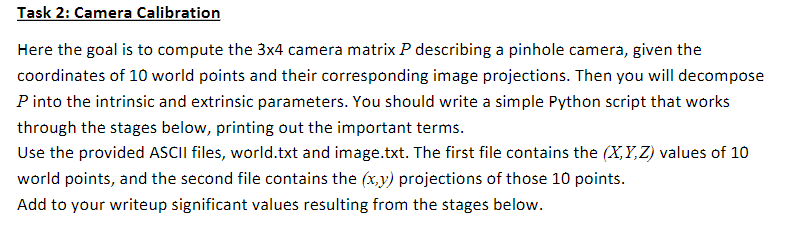

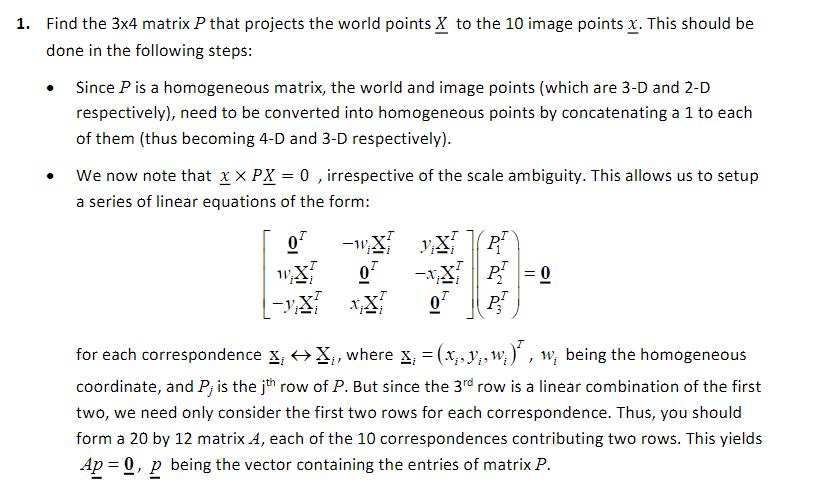

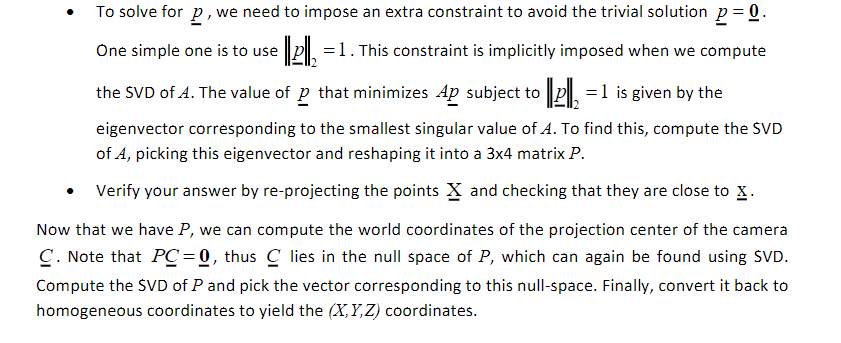

In [5]:
import numpy as np

In [7]:
# Load the world data from the text file
world = np.loadtxt('world.txt', delimiter=',', dtype='float32')
image = np.loadtxt('image2.txt', delimiter=',', dtype='float32')

# Add a column of ones to make homogeneous coordinates
ones = np.ones((world.shape[1], 1), dtype='float32')
world_homogeneous = np.hstack((world.T, ones)).T
image_homogeneous = np.hstack((image.T, ones)).T

# Set up the linear equations for the homogeneous system Ax = 0
A = []
for i in range(world_homogeneous.shape[1]):
    X = world_homogeneous[:, i]
    x, y = image_homogeneous[0, i], image_homogeneous[1, i]
    A.append(np.concatenate((X, np.zeros_like(X), -x * X)))
    A.append(np.concatenate((np.zeros_like(X), X, -y * X)))

A = np.array(A)

# Perform SVD to solve for P
_, _, Vt = np.linalg.svd(A)
P = Vt[-1].reshape(3, 4)

# Verify the camera matrix by re-projecting the points
projected_points = P @ world_homogeneous
projected_points /= projected_points[2]  # Normalize to make them homogeneous

# Print the re-projected points and compare them to the original image points
print("Re-projected points:\n", projected_points)
print("Original image points:\n", image_homogeneous)

# Compute the projection center of the camera
_, _, Vt_P = np.linalg.svd(P)
C = Vt_P[-1]
C /= C[-1]  # Convert to homogeneous coordinates

# Print the significant values
print("Camera matrix P:\n", P)
print("Projection center C (in world coordinates):\n", C[:3])
